In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

print(df.shape)
df.head()

Saving country_wise_latest-selected-columns.csv to country_wise_latest-selected-columns (1).csv
(187, 10)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34
3,Andorra,907,52,803,52,10,0,0,5.73,88.53
4,Angola,950,41,242,667,18,1,0,4.32,25.47


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.info()

['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country/Region         187 non-null    object 
 1   Confirmed              187 non-null    int64  
 2   Deaths                 187 non-null    int64  
 3   Recovered              187 non-null    int64  
 4   Active                 187 non-null    int64  
 5   New cases              187 non-null    int64  
 6   New deaths             187 non-null    int64  
 7   New recovered          187 non-null    int64  
 8   Deaths / 100 Cases     187 non-null    float64
 9   Recovered / 100 Cases  187 non-null    float64
dtypes: float64(2), int64(7), object(1)
memory usage: 14.7+ KB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Country/Region           0
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
New cases                0
New deaths               0
New recovered            0
Deaths / 100 Cases       0
Recovered / 100 Cases    0
dtype: int64

Duplicate Rows: 0


In [ ]:
date_cols = [c for c in df.columns if "date" in c.lower()]
print("Date columns:", date_cols)

if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], errors="coerce")

Date columns: []


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical Columns:", num_cols)
print(df[num_cols].describe())

Numerical Columns: ['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases']
          Confirmed         Deaths     Recovered        Active     New cases  \
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02    187.000000   
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04   1222.957219   
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05   5710.374790   
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02      4.000000   
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03     49.000000   
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03    419.500000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  56336.000000   

        New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  
count   187.000000     187.000000          

In [ ]:
if date_cols and num_cols:
    date_col = date_cols[0]
    value_col = num_cols[0]
    trend = df.groupby(date_col)[value_col].sum()

    plt.figure(figsize=(12,5))
    plt.plot(trend)
    plt.title("COVID-19 Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel(value_col)
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical Columns:", cat_cols)

Categorical Columns: ['Country/Region']


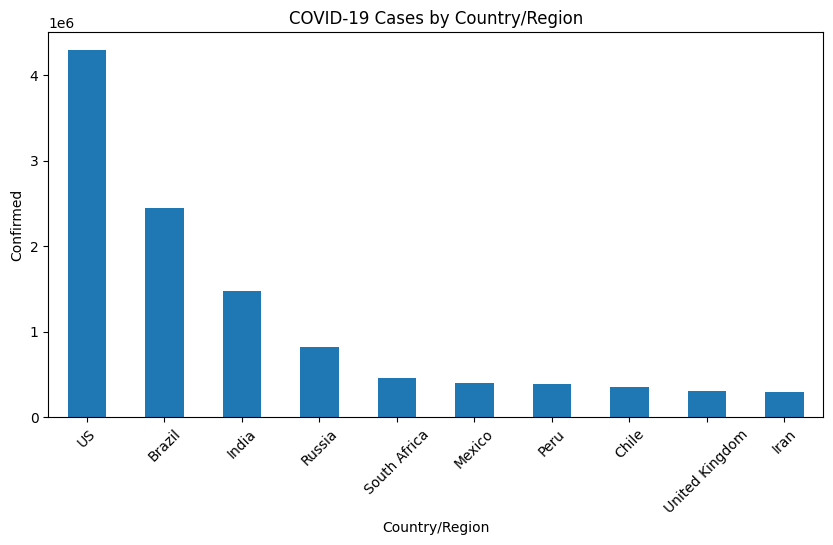

In [ ]:
if cat_cols and num_cols:
    col = cat_cols[0]
    value_col = num_cols[0]
    data = df.groupby(col)[value_col].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10,5))
    data.plot(kind="bar")
    plt.title("COVID-19 Cases by " + col)
    plt.xlabel(col)
    plt.ylabel(value_col)
    plt.xticks(rotation=45)
    plt.show()

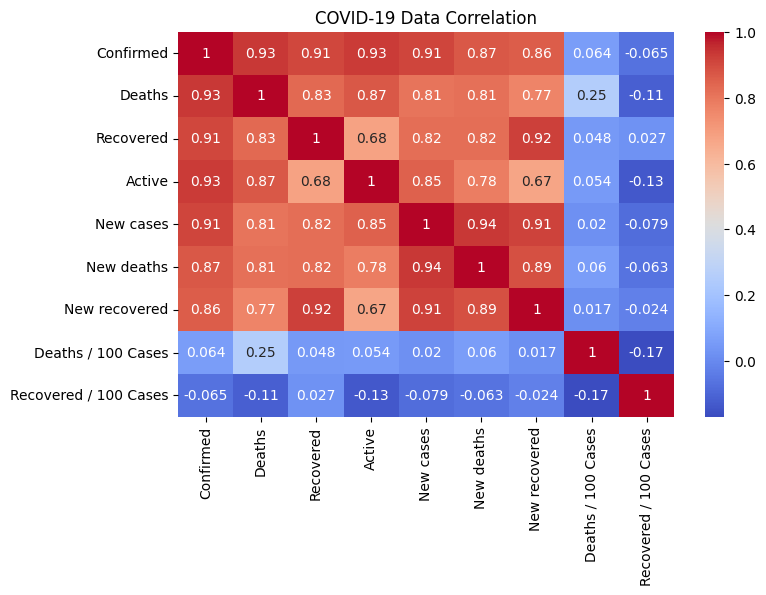

In [ ]:
if len(num_cols) >= 2:
    plt.figure(figsize=(8,5))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("COVID-19 Data Correlation")
    plt.show()

In [ ]:
if num_cols:
    totals = df[num_cols].sum().sort_values(ascending=False)
    print("COVID-19 KPIs")
    print(totals)

COVID-19 KPIs
Confirmed                16480485.00
Recovered                 9468087.00
Active                    6358362.00
Deaths                     654036.00
New cases                  228693.00
New recovered              174623.00
Recovered / 100 Cases       12121.44
New deaths                   5415.00
Deaths / 100 Cases            564.65
dtype: float64


In [ ]:
print("BUSINESS INSIGHTS")
print("1. COVID-19 trends can be monitored over time.")
print("2. High-case regions can be identified for resource allocation.")
print("3. Correlation between numerical variables can reveal important patterns.")
print("4. COVID-19 dashboards can support healthcare and operational planning.")

BUSINESS INSIGHTS
1. COVID-19 trends can be monitored over time.
2. High-case regions can be identified for resource allocation.
3. Correlation between numerical variables can reveal important patterns.
4. COVID-19 dashboards can support healthcare and operational planning.
